In [2]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv

import mtviz as viz
import mmcfilters



In [3]:
imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/images/peppers_gray.tif", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape



In [6]:
AT= mmcfilters.Attribute.Type
tree = mmcfilters.MorphologicalTree(imgInput)
mmcfilters.Attribute.computeAttributes(tree, [AT.AREA, AT.VOLUME, AT.BOX_HEIGHT])

({'AREA': 0, 'VOLUME': 1, 'BOX_HEIGHT': 2},
 array([[2.5000000e+05, 3.2991866e+07, 5.0000000e+02],
        [3.3830000e+04, 3.7804140e+06, 2.0000000e+02],
        [1.1156400e+05, 1.0283698e+07, 4.7800000e+02],
        [8.9290000e+03, 6.4288800e+05, 1.1400000e+02],
        [1.5485000e+04, 8.3619000e+05, 1.8300000e+02],
        [2.4413000e+04, 2.4757900e+06, 2.8100000e+02],
        [1.6137000e+04, 2.2688160e+06, 1.7500000e+02],
        [3.0180000e+03, 1.5665700e+05, 6.8000000e+01],
        [4.2100000e+02, 1.6419000e+04, 2.3000000e+01],
        [6.8210000e+03, 2.5919800e+05, 9.7000000e+01]], dtype=float32))

In [8]:
import pandas as pd
ok = True
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = cv.imread(trainset[i], cv.IMREAD_GRAYSCALE)
    (img_rows, img_cols) = img.shape
    tree = mmcfilters.MorphologicalTree(img)
    features, attrs = mmcfilters.Attribute.computeAttributes(tree, [mmcfilters.Attribute.ALL])
    
    df2 = pd.DataFrame(attrs, columns=features)
    if( len( df2[df2.isna().any(axis=1)]  ) > 0 ):
        print(i, df2[df2.isna().any(axis=1)] )
        ok = False
    #else:
    #    display.display(df2)
if(ok):
    print("Atributos verificados, tudo ok!")

Atributos verificados, tudo ok!


In [10]:
maxtree = mmcfilters.MorphologicalTree(imgInput, True, 1.5)
mintree = mmcfilters.MorphologicalTree(imgInput,False, 1.5)
tos = mmcfilters.MorphologicalTree(imgInput)

filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)

dic, attrs_maxtree = mmcfilters.Attribute.computeAttributes(maxtree, [mmcfilters.Attribute.ALL])
dic, attrs_mintree = mmcfilters.Attribute.computeAttributes(mintree, [mmcfilters.Attribute.ALL])
dic, attrs_tos = mmcfilters.Attribute.computeAttributes(tos, [mmcfilters.Attribute.ALL])
dic

{'AREA': 0,
 'VOLUME': 1,
 'RELATIVE_VOLUME': 2,
 'LEVEL': 3,
 'GRAY_HEIGHT': 4,
 'MEAN_LEVEL': 5,
 'VARIANCE_LEVEL': 6,
 'BOX_WIDTH': 7,
 'BOX_HEIGHT': 8,
 'DIAGONAL_LENGTH': 9,
 'RECTANGULARITY': 10,
 'RATIO_WH': 11,
 'BOX_COL_MIN': 12,
 'BOX_COL_MAX': 13,
 'BOX_ROW_MIN': 14,
 'BOX_ROW_MAX': 15,
 'CENTRAL_MOMENT_20': 16,
 'CENTRAL_MOMENT_02': 17,
 'CENTRAL_MOMENT_11': 18,
 'CENTRAL_MOMENT_30': 19,
 'CENTRAL_MOMENT_03': 20,
 'CENTRAL_MOMENT_21': 21,
 'CENTRAL_MOMENT_12': 22,
 'HU_MOMENT_1': 23,
 'HU_MOMENT_2': 24,
 'HU_MOMENT_3': 25,
 'HU_MOMENT_4': 26,
 'HU_MOMENT_5': 27,
 'HU_MOMENT_6': 28,
 'HU_MOMENT_7': 29,
 'INERTIA': 30,
 'COMPACTNESS': 31,
 'ECCENTRICITY': 32,
 'LENGTH_MAJOR_AXIS': 33,
 'LENGTH_MINOR_AXIS': 34,
 'AXIS_ORIENTATION': 35,
 'CIRCULARITY': 36,
 'HEIGHT_NODE': 37,
 'DEPTH_NODE': 38,
 'IS_LEAF_NODE': 39,
 'IS_ROOT_NODE': 40,
 'NUM_CHILDREN_NODE': 41,
 'NUM_SIBLINGS_NODE': 42,
 'NUM_DESCENDANTS_NODE': 43,
 'NUM_LEAF_DESCENDANTS_NODE': 44,
 'LEAF_RATIO_NODE': 45,
 'BAL

In [12]:
viz.printTree(tos.root, attrs=['id', 'level'])


              0: 203 
   ┌────────────┼─────────────┐
 1: 126       2: 78         4: 54 
   |        ┌───┴────┐            
 3: 72    5: 126   6: 161         
            |        |            
          9: 38    7: 54          
                     |            
                   8: 39 


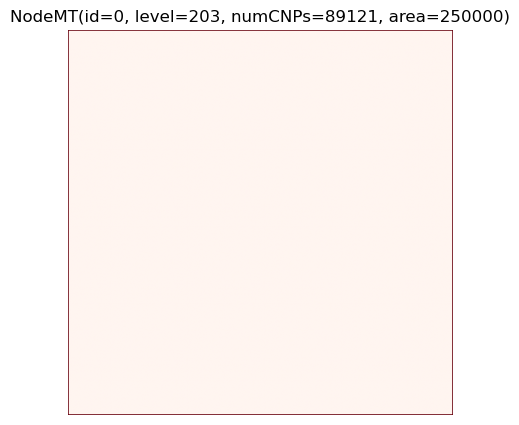

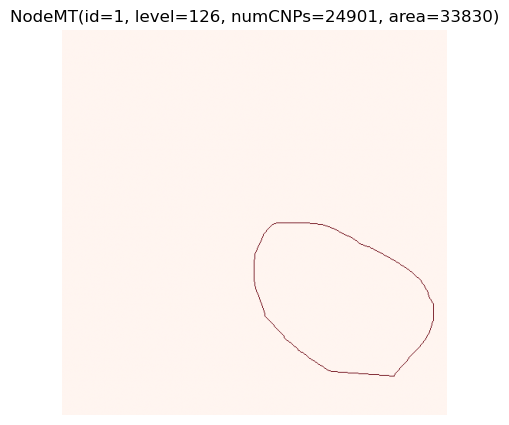

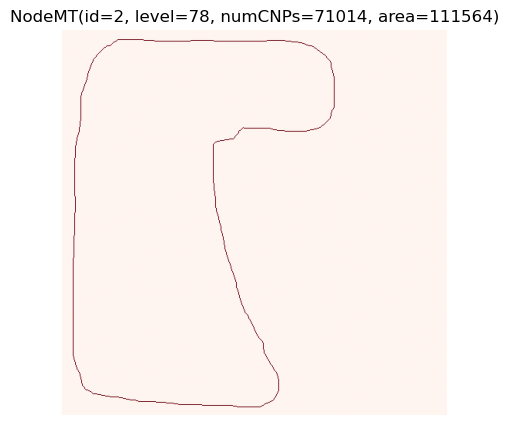

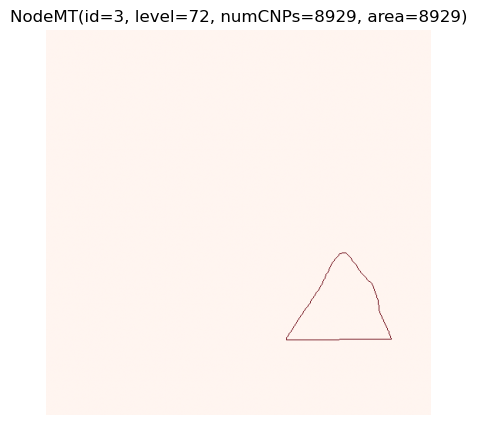

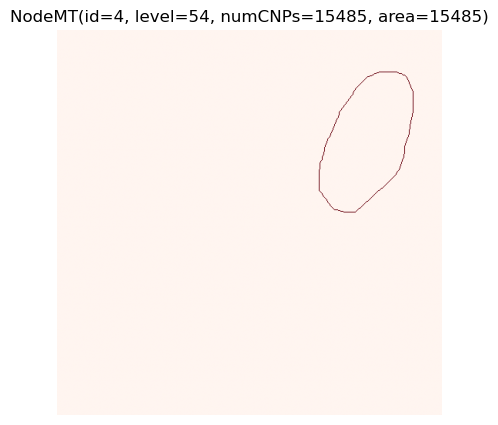

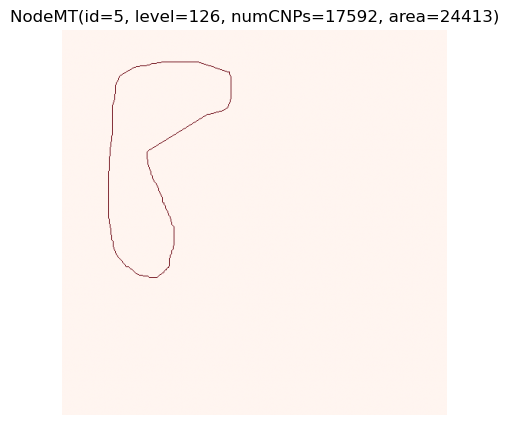

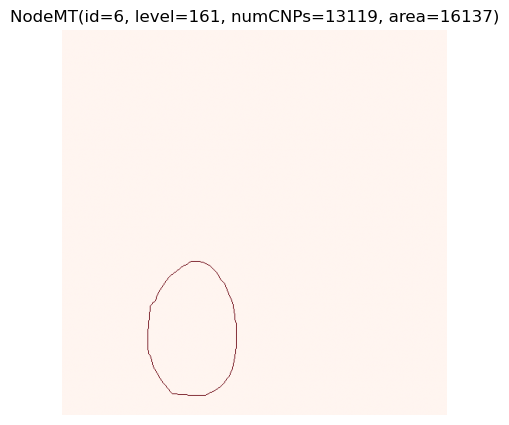

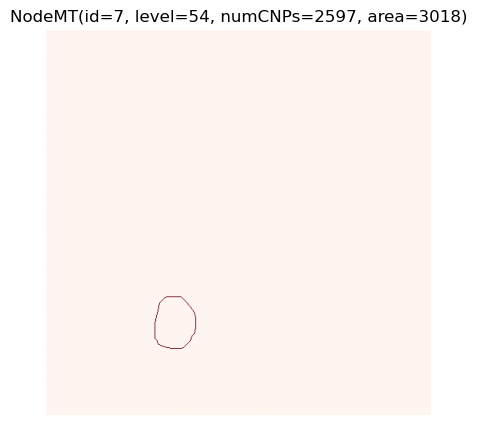

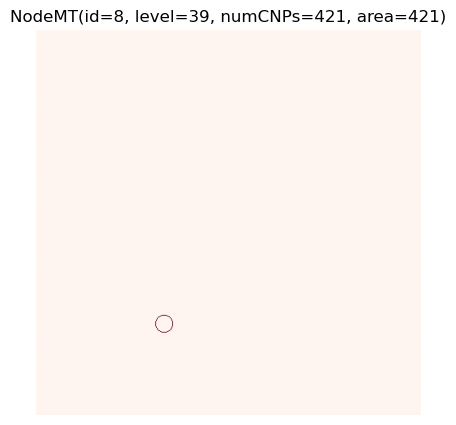

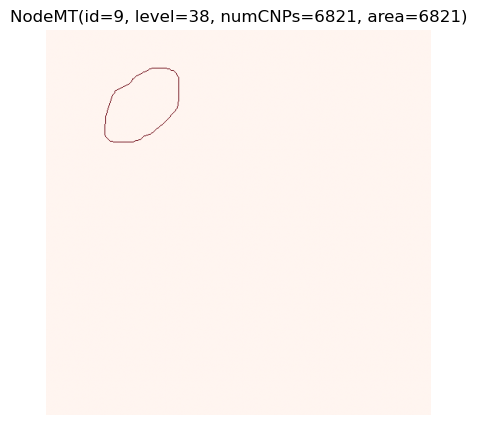

In [16]:
def plotCountors(pixels, node, num_rows, num_cols):
    contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
    
    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_img[row, col] = 255  
    
    # Plotar com matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_img, cmap='Reds')
    plt.title(node)
    plt.axis('off')
    plt.show()

mtContours = mmcfilters.ContourComputation.extraction(tos)
for nodeId, contour in mtContours.contours():
    node = tos.getNode(nodeId)
    if (node.area > 100):
        plotCountors(contour, node, num_rows, num_cols)

Text(0.5, 1.0, 'attribute filter (tos)')

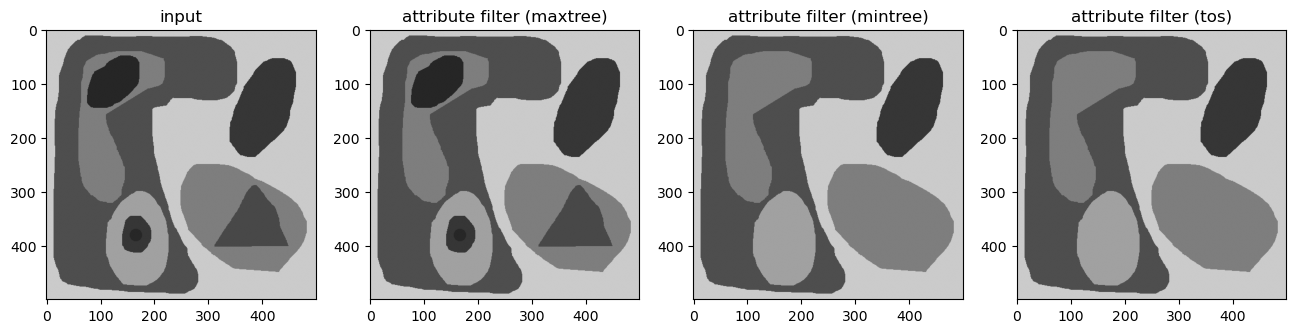

In [18]:
attr_type = mmcfilters.Attribute.Type.AREA
threshold = 10000

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringDirectRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringDirectRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'attribute filter (tos)')

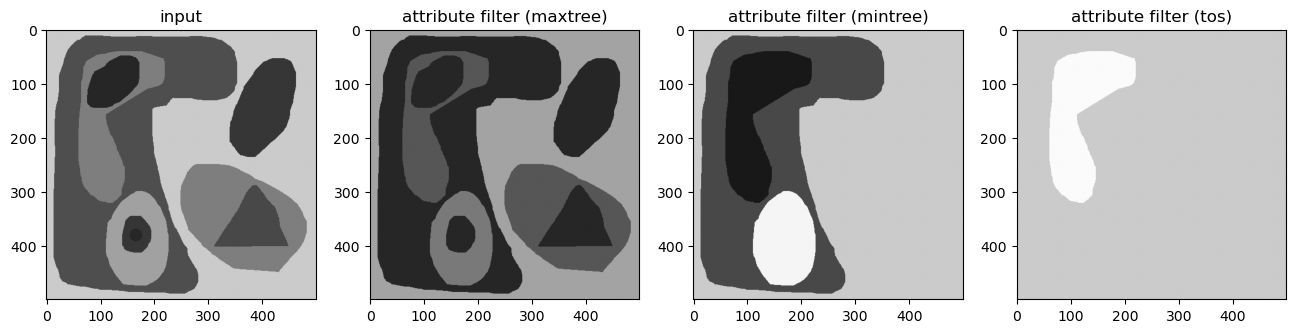

In [20]:
attr_type = mmcfilters.Attribute.Type.INERTIA
threshold = 0.2

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringSubtractiveRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringSubtractiveRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringSubtractiveRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'negative residues')

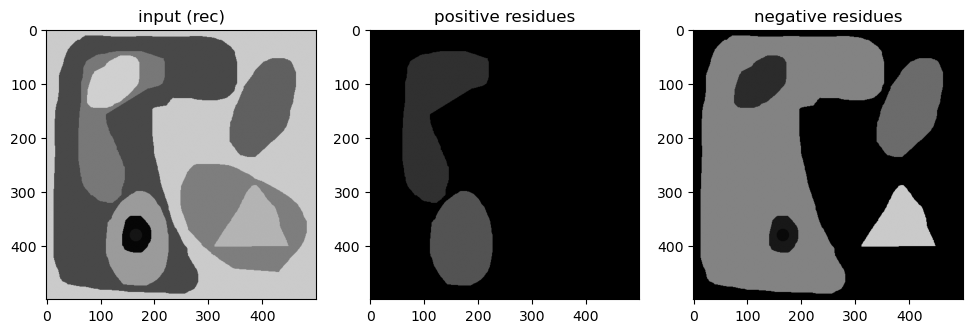

In [22]:
attr_type = mmcfilters.Attribute.Type.BOX_HEIGHT
max_threshold = 300
attr_tos = attrs_tos[:,attr_type]
deltaMSER=5
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tos, attr_tos, max_threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgRest = primitives.restOfImage
imgRec = rtree.reconstruction()
imgPos = rtree.getPositiveResidues()
imgNeg = rtree.getNegativeResidues()

plt.subplot(1,4, 1)
plt.imshow(imgRec, cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgPos, cmap='gray', vmax=255, vmin=0)
plt.title('positive residues')

plt.subplot(1,4, 3)
plt.imshow(imgNeg, cmap='gray', vmax=255, vmin=0)
plt.title('negative residues')


Text(0.5, 1.0, 'residual filter')

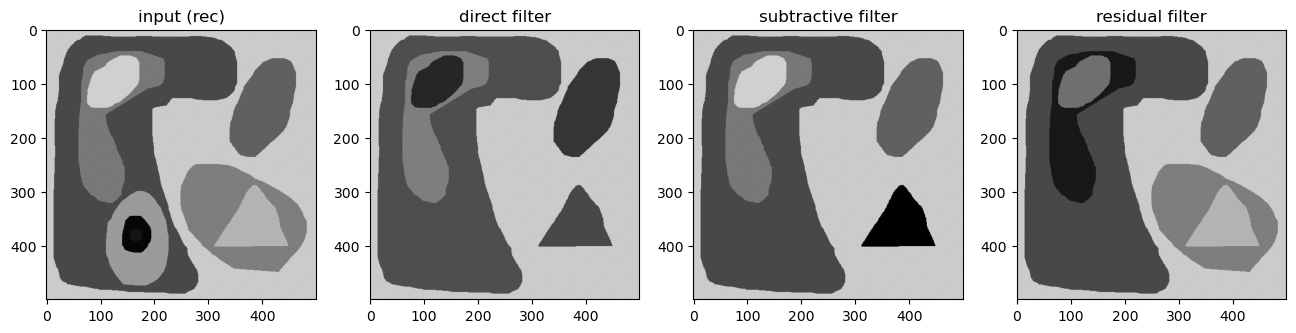

In [24]:
attr_type = mmcfilters.Attribute.Type.INERTIA
threshold = 0.18
att_tos = attrs_tos[:,attr_type]

filterToS = mmcfilters.AttributeFilters(tos)
imgAttrFilter = filterToS.filteringDirectRule(att_tos > threshold)
imgAttrSub = filterToS.filteringSubtractiveRule(att_tos > threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgResFilter = rtree.filtering(att_tos > threshold)

imgRec = rtree.reconstruction()

plt.subplot(1,4, 1)
plt.imshow(imgRec, cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter, cmap='gray', vmax=255, vmin=0)
plt.title('direct filter')

plt.subplot(1,4, 3)
plt.imshow(imgAttrSub, cmap='gray', vmax=255, vmin=0)
plt.title('subtractive filter')


plt.subplot(1,4, 4)
plt.imshow(imgResFilter, cmap='gray', vmax=255, vmin=0)
plt.title('residual filter')
